## Setup and Data Loading

## Setup and Data Loading

In [6]:
# Load required libraries
library(tidyverse)
library(fixest)
library(broom)
library(knitr)
library(scales)
library(gridExtra)

# Set theme for plots
theme_set(theme_minimal(base_size = 14))

cat("Libraries loaded successfully!\n")

Libraries loaded successfully!


In [7]:
# Load the dataset from URL
url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df <- read.csv(url)
# Normalize column names: rename `_nfd` to `X_nfd` (used throughout the notebook)
if ('_nfd' %in% names(df)) df <- df %>% rename(X_nfd = `_nfd`)
# Create an indicator for whether a unit is ever treated (used in TWFE and event study)
if (!'X_treated' %in% names(df)) df <- df %>% mutate(X_treated = ifelse(!is.na(X_nfd) & X_nfd > 0, 1, 0))

# Display basic information
cat("Dataset Shape:", nrow(df), "rows x", ncol(df), "columns\n")
cat("\nColumn Names:\n")
print(names(df))
cat("\nFirst few rows:\n")
head(df, 10)

Dataset Shape: 1617 rows x 11 columns

Column Names:
 [1] "stfips"    "year"      "X_nfd"     "post"      "asmrs"     "pcinc"    
 [7] "asmrh"     "cases"     "weight"    "copop"     "X_treated"

First few rows:

Column Names:
 [1] "stfips"    "year"      "X_nfd"     "post"      "asmrs"     "pcinc"    
 [7] "asmrh"     "cases"     "weight"    "copop"     "X_treated"

First few rows:


,stfips,year,X_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,X_treated
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1964,1971,0,35.63988,12406.18,5.007341,0.012312243,1715156,1715156,1
2,1,1965,1971,0,41.54375,13070.21,4.425367,0.010419407,1715156,1725186,1
3,1,1966,1971,0,34.25233,13526.66,4.874819,0.009900097,1715156,1735219,1
4,1,1967,1971,0,34.46502,13918.19,5.362014,0.009974692,1715156,1745250,1
5,1,1968,1971,0,40.44011,14684.81,4.643759,0.012400659,1715156,1755283,1
6,1,1969,1971,0,42.49012,15638.88,5.296976,0.015006756,1715156,1765316,1
7,1,1970,1971,0,44.23907,16222.95,4.716939,0.019703142,1715156,1787363,1
8,1,1971,1971,1,49.91467,16875.43,4.992504,0.022737451,1715156,1809412,1
9,1,1972,1971,1,47.20313,17976.76,5.187023,0.023555981,1715156,1831191,1


In [8]:
# Check data structure and summary statistics
cat("Data Structure:\n")
str(df)

cat("\nSummary Statistics:\n")
summary(df)

Data Structure:
'data.frame':	1617 obs. of  11 variables:
 $ stfips   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ year     : int  1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 ...
 $ X_nfd    : int  1971 1971 1971 1971 1971 1971 1971 1971 1971 1971 ...
 $ post     : int  0 0 0 0 0 0 0 1 1 1 ...
 $ asmrs    : num  35.6 41.5 34.3 34.5 40.4 ...
 $ pcinc    : num  12406 13070 13527 13918 14685 ...
 $ asmrh    : num  5.01 4.43 4.87 5.36 4.64 ...
 $ cases    : num  0.01231 0.01042 0.0099 0.00997 0.0124 ...
 $ weight   : num  1715156 1715156 1715156 1715156 1715156 ...
 $ copop    : num  1715156 1725186 1735219 1745250 1755283 ...
 $ X_treated: num  1 1 1 1 1 1 1 1 1 1 ...
'data.frame':	1617 obs. of  11 variables:
 $ stfips   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ year     : int  1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 ...
 $ X_nfd    : int  1971 1971 1971 1971 1971 1971 1971 1971 1971 1971 ...
 $ post     : int  0 0 0 0 0 0 0 1 1 1 ...
 $ asmrs    : num  35.6 41.5 34.3 34.5 40.4 ...
 $ pcinc 

     stfips          year          X_nfd           post       
 Min.   : 1.0   Min.   :1964   Min.   :1969   Min.   :0.0000  
 1st Qu.:18.0   1st Qu.:1972   1st Qu.:1971   1st Qu.:0.0000  
 Median :30.0   Median :1980   Median :1973   Median :1.0000  
 Mean   :29.8   Mean   :1980   Mean   :1974   Mean   :0.6846  
 3rd Qu.:42.0   3rd Qu.:1988   3rd Qu.:1974   3rd Qu.:1.0000  
 Max.   :56.0   Max.   :1996   Max.   :1985   Max.   :1.0000  
                               NA's   :429                    
     asmrs             pcinc           asmrh            cases         
 Min.   :  7.477   Min.   :10275   Min.   : 0.000   Min.   :0.003131  
 1st Qu.: 40.238   1st Qu.:21462   1st Qu.: 2.166   1st Qu.:0.015990  
 Median : 48.842   Median :25783   Median : 3.207   Median :0.023150  
 Mean   : 52.166   Mean   :26081   Mean   : 3.439   Mean   :0.024491  
 3rd Qu.: 60.036   3rd Qu.:30008   3rd Qu.: 4.356   3rd Qu.:0.031429  
 Max.   :185.971   Max.   :48822   Max.   :19.134   Max.   :0.088966  

In [9]:
# Examine treatment structure
cat("Unique treatment years (X_nfd - treatment timing):\n")
print(sort(unique(df$X_nfd)))

cat("\nNumber of units (states):", length(unique(df$stfips)), "\n")
cat("Time period range:", min(df$year), "to", max(df$year), "\n")

# Treatment timing distribution
cat("\nTreatment cohort distribution:\n")
table(df$X_nfd)

Unique treatment years (X_nfd - treatment timing):
 [1] 1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985

Number of units (states): 49 
 [1] 1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985

Number of units (states): 49 
Time period range: 1964 to 1996 
Time period range: 1964 to 1996 

Treatment cohort distribution:

Treatment cohort distribution:



1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985 
  66   66  231   99  330   99   66   33   99   33   33   33 

---

## Part a) Two-Way Fixed Effects (TWFE) Regression

The TWFE model specification:

$$Y_{it} = \alpha_i + \gamma_t + \beta \cdot D_{it} + X_{it}'\delta + \epsilon_{it}$$

Using the `fixest` package for efficient fixed effects estimation with clustered standard errors.

In [10]:
# Create treatment indicator (post × treated)
df$treated_post <- df$post * df$X_treated

# Verify treatment indicator
cat("Treatment indicator distribution:\n")
df %>%
  group_by(X_treated, post) %>%
  summarize(mean_treated_post = mean(treated_post), n = n(), .groups = 'drop') %>%
  print()

Treatment indicator distribution:
# A tibble: 4 x 4
  X_treated  post mean_treated_post     n
      <dbl> <int>             <dbl> <int>
1         0     0                 0   165
2         0     1                 0   264
3         1     0                 0   345
4         1     1                 1   843
# A tibble: 4 x 4
  X_treated  post mean_treated_post     n
      <dbl> <int>             <dbl> <int>
1         0     0                 0   165
2         0     1                 0   264
3         1     0                 0   345
4         1     1                 1   843


In [11]:
# Estimate TWFE model using fixest
twfe_model <- feols(
  asmrs ~ treated_post + pcinc + asmrh + cases | stfips + year,
  data = df,
  cluster = ~stfips
)

cat("========================================================================\n")
cat("TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS\n")
cat("========================================================================\n")
summary(twfe_model)

TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS
TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS


OLS estimation, Dep. Var.: asmrs
Observations: 1,617
Fixed-effects: stfips: 49,  year: 33
Standard-errors: Clustered (stfips) 
                Estimate Std. Error  t value Pr(>|t|)    
treated_post   -2.515964   2.283101 -1.10199 0.275959    
pcinc          -0.001118   0.000361 -3.09434 0.003286 ** 
asmrh           1.184598   0.576545  2.05465 0.045378 *  
cases        -178.517916 137.973884 -1.29385 0.201907    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 10.6     Adj. R2: 0.693695
             Within R2: 0.034601

In [12]:
# Create summary table for TWFE results
twfe_summary <- tidy(twfe_model, conf.int = TRUE) %>%
  mutate(
    significance = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01 ~ "**",
      p.value < 0.05 ~ "*",
      p.value < 0.1 ~ ".",
      TRUE ~ ""
    )
  )

cat("\n========================================================================\n")
cat("TWFE COEFFICIENT SUMMARY TABLE\n")
cat("========================================================================\n")
print(twfe_summary)

# Store TWFE coefficient
twfe_coef <- coef(twfe_model)["treated_post"]
twfe_se <- sqrt(vcov(twfe_model)["treated_post", "treated_post"])
cat(sprintf("\n*** TWFE Treatment Effect: %.4f (SE: %.4f) ***\n", twfe_coef, twfe_se))


TWFE COEFFICIENT SUMMARY TABLE
TWFE COEFFICIENT SUMMARY TABLE
# A tibble: 4 x 8
  term      estimate std.error statistic p.value conf.low conf.high significance
  <chr>        <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl> <chr>       
1 treated_~ -2.52e+0   2.28e+0     -1.10 0.276   -7.11e+0  2.07     ""          
2 pcinc     -1.12e-3   3.61e-4     -3.09 0.00329 -1.84e-3 -0.000392 "**"        
3 asmrh      1.18e+0   5.77e-1      2.05 0.0454   2.54e-2  2.34     "*"         
4 cases     -1.79e+2   1.38e+2     -1.29 0.202   -4.56e+2 98.9      ""          

*** TWFE Treatment Effect: -2.5160 (SE: 2.2831) ***
# A tibble: 4 x 8
  term      estimate std.error statistic p.value conf.low conf.high significance
  <chr>        <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl> <chr>       
1 treated_~ -2.52e+0   2.28e+0     -1.10 0.276   -7.11e+0  2.07     ""          
2 pcinc     -1.12e-3   3.61e-4     -3.09 0.00329 -1.84e-3 -0.000392 "**"        
3 asmrh      1.18e+0   5.77e-1      2.

---

## Part b) Cleaning for Event-Study

### Step 1: Create the Relative Time Variable

In [13]:
# Create event study dataset
df_es <- df %>%
  mutate(
    treatment_year = X_nfd,
    event_time = ifelse(treatment_year > 0, year - treatment_year, NA)
  )

cat("Relative time variable created!\n")
cat("\nSample of data with event time:\n")
df_es %>%
  select(stfips, year, treatment_year, event_time, asmrs) %>%
  head(20)

Relative time variable created!

Sample of data with event time:

Sample of data with event time:


,stfips,year,treatment_year,event_time,asmrs
,<int>,<int>,<int>,<int>,<dbl>
1,1,1964,1971,-7,35.63988
2,1,1965,1971,-6,41.54375
3,1,1966,1971,-5,34.25233
4,1,1967,1971,-4,34.46502
5,1,1968,1971,-3,40.44011
6,1,1969,1971,-2,42.49012
7,1,1970,1971,-1,44.23907
8,1,1971,1971,0,49.91467
9,1,1972,1971,1,47.20313


### Step 2: Frequency Table of Event Time

In [14]:
# Create frequency table for event time
event_time_freq <- df_es %>%
  filter(!is.na(event_time)) %>%
  count(event_time) %>%
  arrange(event_time) %>%
  mutate(
    percentage = round(n / sum(n) * 100, 2),
    cumulative_pct = round(cumsum(percentage), 2)
  )

cat("========================================================================\n")
cat("FREQUENCY TABLE OF EVENT TIME (RELATIVE TIME)\n")
cat("========================================================================\n")
print(event_time_freq)

cat(sprintf("\nTotal observations with event time: %d\n", sum(event_time_freq$n)))
cat(sprintf("Never-treated observations: %d\n", sum(is.na(df_es$event_time))))

FREQUENCY TABLE OF EVENT TIME (RELATIVE TIME)
FREQUENCY TABLE OF EVENT TIME (RELATIVE TIME)
   event_time  n percentage cumulative_pct
1         -21  1       0.08           0.08
2         -20  2       0.17           0.25
3         -19  2       0.17           0.42
4         -18  2       0.17           0.59
5         -17  2       0.17           0.76
6         -16  3       0.25           1.01
7         -15  3       0.25           1.26
8         -14  3       0.25           1.51
9         -13  6       0.51           2.02
10        -12  7       0.59           2.61
11        -11  9       0.76           3.37
12        -10 12       1.01           4.38
13         -9 22       1.85           6.23
14         -8 25       2.10           8.33
15         -7 32       2.69          11.02
16         -6 34       2.86          13.88
17         -5 36       3.03          16.91
18         -4 36       3.03          19.94
19         -3 36       3.03          22.97
20         -2 36       3.03          26.00
21   

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."



Figure saved to: ../output/event_time_distribution.png

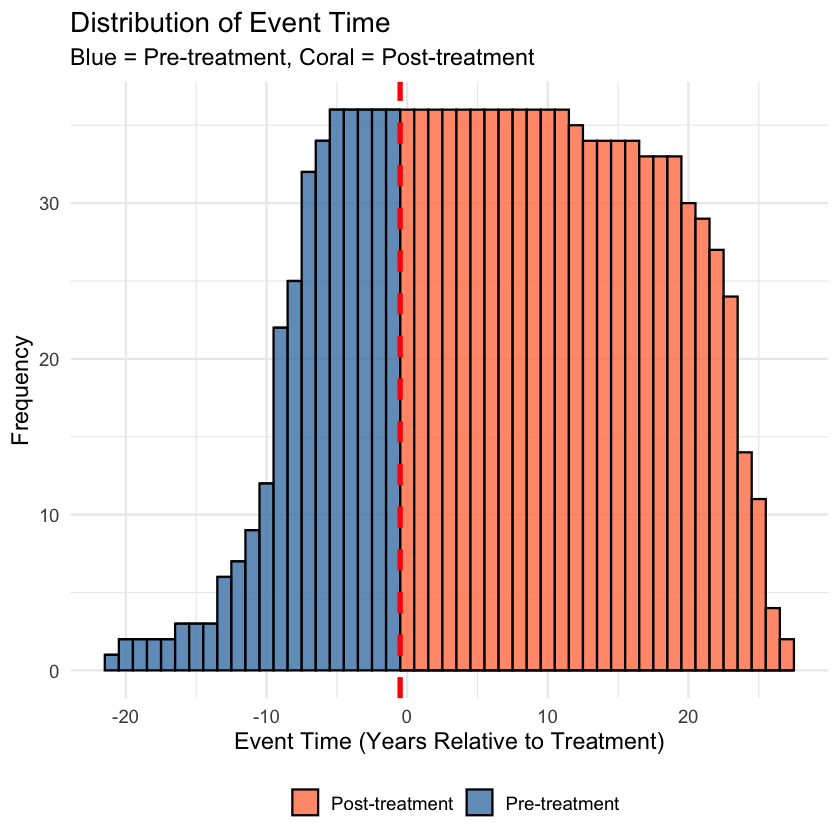

In [15]:
# Visualize event time distribution
event_time_plot <- df_es %>%
  filter(!is.na(event_time)) %>%
  ggplot(aes(x = event_time, fill = event_time < 0)) +
  geom_histogram(binwidth = 1, color = "black", alpha = 0.8) +
  geom_vline(xintercept = -0.5, color = "red", linetype = "dashed", size = 1.5) +
  scale_fill_manual(values = c("coral", "steelblue"), 
                    labels = c("Post-treatment", "Pre-treatment"),
                    name = "") +
  labs(
    title = "Distribution of Event Time",
    subtitle = "Blue = Pre-treatment, Coral = Post-treatment",
    x = "Event Time (Years Relative to Treatment)",
    y = "Frequency"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")

print(event_time_plot)

ggsave("../output/event_time_distribution.png", event_time_plot, 
       width = 12, height = 6, dpi = 300)
cat("\nFigure saved to: ../output/event_time_distribution.png")

### Step 3: Choose Bounds and Create Binned Event Time

In [16]:
# Analyze distribution for bounds
event_times <- df_es$event_time[!is.na(df_es$event_time)]

cat("Percentiles of Event Time:\n")
print(quantile(event_times, probs = c(0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95)))

cat("\nRecommended bounds: -10 to 10\n")

Percentiles of Event Time:
 5% 10% 25% 50% 75% 90% 95% 
 -9  -7  -2   6  15  20  22 

Recommended bounds: -10 to 10
 5% 10% 25% 50% 75% 90% 95% 
 -9  -7  -2   6  15  20  22 

Recommended bounds: -10 to 10


In [17]:
# Set bounds and create binned event time
LOWER_BOUND <- -10
UPPER_BOUND <- 10

df_es <- df_es %>%
  mutate(
    event_time_binned = case_when(
      is.na(event_time) ~ NA_real_,
      event_time < LOWER_BOUND ~ LOWER_BOUND,
      event_time > UPPER_BOUND ~ UPPER_BOUND,
      TRUE ~ event_time
    )
  )

cat(sprintf("Event time binned to range [%d, %d]\n", LOWER_BOUND, UPPER_BOUND))

Event time binned to range [-10, 10]


### Step 4: Why Group Distant Event Times?

**Answer:**

1. **Statistical Power**: Few observations at extremes lead to imprecise estimates
2. **Avoiding Multicollinearity**: Many dummies with few observations cause collinearity issues
3. **Focus on Relevant Window**: Policy-relevant dynamics occur close to treatment
4. **Composition Effects**: Only certain cohorts contribute at extreme lags
5. **Practical Interpretation**: Effects 20+ years from treatment are hard to interpret

### Step 5: Create Event Time Factor for Regression

In [18]:
# Filter to treated units and create factor
df_es_treated <- df_es %>%
  filter(treatment_year > 0) %>%
  mutate(
    event_time_factor = factor(event_time_binned),
    event_time_factor = relevel(event_time_factor, ref = "-1")
  )

cat("Event time factor levels:\n")
print(levels(df_es_treated$event_time_factor))
cat(sprintf("\nObservations for event study: %d\n", nrow(df_es_treated)))

Event time factor levels:
 [1] "-1"  "-10" "-9"  "-8"  "-7"  "-6"  "-5"  "-4"  "-3"  "-2"  "0"   "1"  
[13] "2"   "3"   "4"   "5"   "6"   "7"   "8"   "9"   "10" 

Observations for event study: 1188
 [1] "-1"  "-10" "-9"  "-8"  "-7"  "-6"  "-5"  "-4"  "-3"  "-2"  "0"   "1"  
[13] "2"   "3"   "4"   "5"   "6"   "7"   "8"   "9"   "10" 

Observations for event study: 1188


---

## Part c) Event-Study Estimation

In [19]:
# Estimate Event-Study model
event_study_model <- feols(
  asmrs ~ event_time_factor + pcinc + asmrh + cases | stfips + year,
  data = df_es_treated,
  cluster = ~stfips
)

cat("========================================================================\n")
cat("EVENT-STUDY REGRESSION RESULTS\n")
cat("========================================================================\n")
summary(event_study_model)

EVENT-STUDY REGRESSION RESULTS
EVENT-STUDY REGRESSION RESULTS


OLS estimation, Dep. Var.: asmrs
Observations: 1,188
Fixed-effects: stfips: 36,  year: 33
Standard-errors: Clustered (stfips) 
                        Estimate Std. Error   t value Pr(>|t|) 
event_time_factor-10   -6.148791   7.718843 -0.796595  0.43106 
event_time_factor-9    -7.318022   6.115817 -1.196573  0.23952 
event_time_factor-8    -4.430764   5.957583 -0.743718  0.46201 
event_time_factor-7    -2.708891   5.819362 -0.465496  0.64446 
event_time_factor-6    -2.136785   4.513974 -0.473371  0.63889 
event_time_factor-5    -3.788089   3.545175 -1.068520  0.29260 
event_time_factor-4    -0.619333   2.840652 -0.218025  0.82868 
event_time_factor-3    -3.139643   2.975579 -1.055137  0.29859 
event_time_factor-2    -0.654568   2.444916 -0.267726  0.79048 
event_time_factor0      1.209878   2.803174  0.431610  0.66867 
event_time_factor1     -0.312555   3.448384 -0.090638  0.92830 
event_time_factor2      0.765940   4.658407  0.164421  0.87035 
event_time_factor3      1.893053   3.5673

In [20]:
# Extract coefficients
es_results <- tidy(event_study_model, conf.int = TRUE) %>%
  filter(str_detect(term, "event_time_factor")) %>%
  mutate(
    event_time = as.numeric(str_extract(term, "-?\\d+")),
    coefficient = estimate,
    std_error = std.error,
    ci_lower = conf.low,
    ci_upper = conf.high
  ) %>%
  select(event_time, coefficient, std_error, ci_lower, ci_upper, statistic, p.value)

# Add reference period
reference_row <- tibble(
  event_time = -1,
  coefficient = 0,
  std_error = 0,
  ci_lower = 0,
  ci_upper = 0,
  statistic = NA_real_,
  p.value = NA_real_
)

es_results <- bind_rows(es_results, reference_row) %>%
  arrange(event_time)

cat("========================================================================\n")
cat("EVENT-STUDY COEFFICIENTS TABLE\n")
cat("========================================================================\n")
print(es_results)

EVENT-STUDY COEFFICIENTS TABLE
EVENT-STUDY COEFFICIENTS TABLE
# A tibble: 21 x 7
   event_time coefficient std_error ci_lower ci_upper statistic p.value
        <dbl>       <dbl>     <dbl>    <dbl>    <dbl>     <dbl>   <dbl>
 1        -10      -6.15       7.72   -21.8      9.52    -0.797   0.431
 2         -9      -7.32       6.12   -19.7      5.10    -1.20    0.240
 3         -8      -4.43       5.96   -16.5      7.66    -0.744   0.462
 4         -7      -2.71       5.82   -14.5      9.11    -0.465   0.644
 5         -6      -2.14       4.51   -11.3      7.03    -0.473   0.639
 6         -5      -3.79       3.55   -11.0      3.41    -1.07    0.293
 7         -4      -0.619      2.84    -6.39     5.15    -0.218   0.829
 8         -3      -3.14       2.98    -9.18     2.90    -1.06    0.299
 9         -2      -0.655      2.44    -5.62     4.31    -0.268   0.790
10         -1       0          0        0        0       NA      NA    
# i 11 more rows
# A tibble: 21 x 7
   event_time coeff

In [21]:
# Save results
write.csv(es_results, "../output/event_study_coefficients.csv", row.names = FALSE)
cat("Results saved to: ../output/event_study_coefficients.csv")

Results saved to: ../output/event_study_coefficients.csv


Figure saved to: ../output/event_study_plot.png

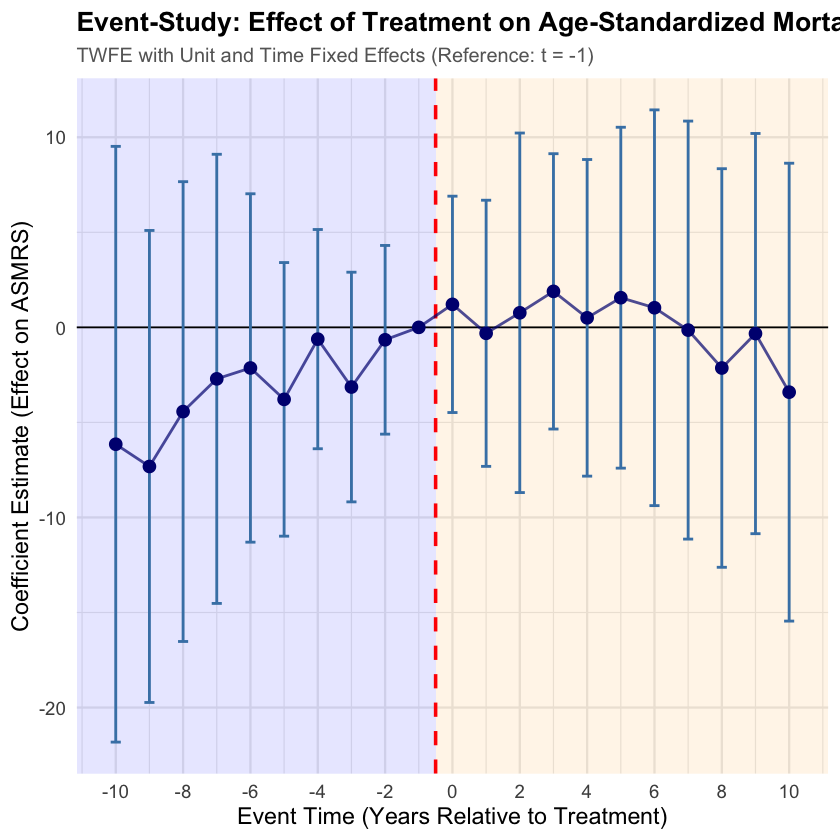

In [22]:
# Create Event-Study Plot
es_plot <- ggplot(es_results, aes(x = event_time, y = coefficient)) +
  annotate("rect", xmin = -Inf, xmax = -0.5, ymin = -Inf, ymax = Inf, 
           fill = "blue", alpha = 0.1) +
  annotate("rect", xmin = -0.5, xmax = Inf, ymin = -Inf, ymax = Inf, 
           fill = "orange", alpha = 0.1) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = -0.5, color = "red", linetype = "dashed", size = 1) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
                width = 0.3, color = "steelblue", size = 0.8) +
  geom_line(color = "navy", alpha = 0.7, size = 0.8) +
  geom_point(color = "navy", size = 3) +
  labs(
    title = "Event-Study: Effect of Treatment on Age-Standardized Mortality Rate",
    subtitle = "TWFE with Unit and Time Fixed Effects (Reference: t = -1)",
    x = "Event Time (Years Relative to Treatment)",
    y = "Coefficient Estimate (Effect on ASMRS)"
  ) +
  scale_x_continuous(breaks = seq(LOWER_BOUND, UPPER_BOUND, by = 2)) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 12, color = "gray40")
  )

print(es_plot)

ggsave("../output/event_study_plot.png", es_plot, 
       width = 14, height = 8, dpi = 300)
cat("\nFigure saved to: ../output/event_study_plot.png")

---

## Summary

In [23]:
# Final summary
cat("========================================================================\n")
cat("SUMMARY OF QUESTION 1 RESULTS (R)\n")
cat("========================================================================\n")

cat(sprintf("\nTWFE Treatment Effect: %.4f (SE: %.4f)\n", twfe_coef, twfe_se))

pre_treatment <- es_results %>% filter(event_time < 0)
post_treatment <- es_results %>% filter(event_time >= 0)

cat("\nEvent-Study Coefficients Range:\n")
cat(sprintf("  Pre-treatment (t<0): %.4f to %.4f\n", 
            min(pre_treatment$coefficient), max(pre_treatment$coefficient)))
cat(sprintf("  Post-treatment (t>=0): %.4f to %.4f\n", 
            min(post_treatment$coefficient), max(post_treatment$coefficient)))

cat("\nOutput files generated:\n")
cat("  - event_time_distribution.png\n")
cat("  - event_study_plot.png\n")
cat("  - event_study_coefficients.csv\n")

SUMMARY OF QUESTION 1 RESULTS (R)

TWFE Treatment Effect: -2.5160 (SE: 2.2831)
SUMMARY OF QUESTION 1 RESULTS (R)

TWFE Treatment Effect: -2.5160 (SE: 2.2831)

Event-Study Coefficients Range:
  Pre-treatment (t<0): -7.3180 to 0.0000
  Post-treatment (t>=0): -3.4091 to 1.8931

Output files generated:
  - event_time_distribution.png
  - event_study_plot.png
  - event_study_coefficients.csv

Event-Study Coefficients Range:
  Pre-treatment (t<0): -7.3180 to 0.0000
  Post-treatment (t>=0): -3.4091 to 1.8931

Output files generated:
  - event_time_distribution.png
  - event_study_plot.png
  - event_study_coefficients.csv


In [24]:
# Load required libraries
library(tidyverse)
library(fixest)
library(broom)
library(knitr)
library(kableExtra)
library(scales)
library(gridExtra)

# Set theme for plots
theme_set(theme_minimal(base_size = 14))

cat("Libraries loaded successfully!\n")


Attaching package: 'kableExtra'


The following object is masked from 'package:dplyr':

    group_rows


The following object is masked from 'package:dplyr':

    group_rows




Libraries loaded successfully!


In [25]:
# Load the dataset from URL
url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df <- read.csv(url)
# Normalize column names: rename `_nfd` to `X_nfd` (used throughout the notebook)
if ('_nfd' %in% names(df)) df <- df %>% rename(X_nfd = `_nfd`)
# Create an indicator for whether a unit is ever treated (used in TWFE and event study)
if (!'X_treated' %in% names(df)) df <- df %>% mutate(X_treated = ifelse(!is.na(X_nfd) & X_nfd > 0, 1, 0))

# Display basic information
cat("Dataset Shape:", nrow(df), "rows x", ncol(df), "columns\n")
cat("\nColumn Names:\n")
print(names(df))
cat("\nFirst few rows:\n")
head(df, 10)

Dataset Shape: 1617 rows x 11 columns

Column Names:
 [1] "stfips"    "year"      "X_nfd"     "post"      "asmrs"     "pcinc"    
 [7] "asmrh"     "cases"     "weight"    "copop"     "X_treated"

First few rows:

Column Names:
 [1] "stfips"    "year"      "X_nfd"     "post"      "asmrs"     "pcinc"    
 [7] "asmrh"     "cases"     "weight"    "copop"     "X_treated"

First few rows:


,stfips,year,X_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,X_treated
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1964,1971,0,35.63988,12406.18,5.007341,0.012312243,1715156,1715156,1
2,1,1965,1971,0,41.54375,13070.21,4.425367,0.010419407,1715156,1725186,1
3,1,1966,1971,0,34.25233,13526.66,4.874819,0.009900097,1715156,1735219,1
4,1,1967,1971,0,34.46502,13918.19,5.362014,0.009974692,1715156,1745250,1
5,1,1968,1971,0,40.44011,14684.81,4.643759,0.012400659,1715156,1755283,1
6,1,1969,1971,0,42.49012,15638.88,5.296976,0.015006756,1715156,1765316,1
7,1,1970,1971,0,44.23907,16222.95,4.716939,0.019703142,1715156,1787363,1
8,1,1971,1971,1,49.91467,16875.43,4.992504,0.022737451,1715156,1809412,1
9,1,1972,1971,1,47.20313,17976.76,5.187023,0.023555981,1715156,1831191,1


In [26]:
# Check data structure and summary statistics
cat("Data Structure:\n")
str(df)

cat("\nSummary Statistics:\n")
summary(df)

Data Structure:
'data.frame':	1617 obs. of  11 variables:
 $ stfips   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ year     : int  1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 ...
 $ X_nfd    : int  1971 1971 1971 1971 1971 1971 1971 1971 1971 1971 ...
 $ post     : int  0 0 0 0 0 0 0 1 1 1 ...
 $ asmrs    : num  35.6 41.5 34.3 34.5 40.4 ...
 $ pcinc    : num  12406 13070 13527 13918 14685 ...
 $ asmrh    : num  5.01 4.43 4.87 5.36 4.64 ...
 $ cases    : num  0.01231 0.01042 0.0099 0.00997 0.0124 ...
 $ weight   : num  1715156 1715156 1715156 1715156 1715156 ...
 $ copop    : num  1715156 1725186 1735219 1745250 1755283 ...
 $ X_treated: num  1 1 1 1 1 1 1 1 1 1 ...

Summary Statistics:
'data.frame':	1617 obs. of  11 variables:
 $ stfips   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ year     : int  1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 ...
 $ X_nfd    : int  1971 1971 1971 1971 1971 1971 1971 1971 1971 1971 ...
 $ post     : int  0 0 0 0 0 0 0 1 1 1 ...
 $ asmrs    : num  35.6 41.5 34.3 34

     stfips          year          X_nfd           post       
 Min.   : 1.0   Min.   :1964   Min.   :1969   Min.   :0.0000  
 1st Qu.:18.0   1st Qu.:1972   1st Qu.:1971   1st Qu.:0.0000  
 Median :30.0   Median :1980   Median :1973   Median :1.0000  
 Mean   :29.8   Mean   :1980   Mean   :1974   Mean   :0.6846  
 3rd Qu.:42.0   3rd Qu.:1988   3rd Qu.:1974   3rd Qu.:1.0000  
 Max.   :56.0   Max.   :1996   Max.   :1985   Max.   :1.0000  
                               NA's   :429                    
     asmrs             pcinc           asmrh            cases         
 Min.   :  7.477   Min.   :10275   Min.   : 0.000   Min.   :0.003131  
 1st Qu.: 40.238   1st Qu.:21462   1st Qu.: 2.166   1st Qu.:0.015990  
 Median : 48.842   Median :25783   Median : 3.207   Median :0.023150  
 Mean   : 52.166   Mean   :26081   Mean   : 3.439   Mean   :0.024491  
 3rd Qu.: 60.036   3rd Qu.:30008   3rd Qu.: 4.356   3rd Qu.:0.031429  
 Max.   :185.971   Max.   :48822   Max.   :19.134   Max.   :0.088966  

In [27]:
# Examine treatment structure
cat("Unique treatment years (X_nfd - treatment timing):\n")
print(sort(unique(df$X_nfd)))

cat("\nNumber of units (states):", length(unique(df$stfips)), "\n")
cat("Time period range:", min(df$year), "to", max(df$year), "\n")

# Treatment timing distribution
cat("\nTreatment cohort distribution:\n")
table(df$X_nfd)

Unique treatment years (X_nfd - treatment timing):
 [1] 1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985

Number of units (states): 49 
Time period range: 1964 to 1996 

Treatment cohort distribution:
 [1] 1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985

Number of units (states): 49 
Time period range: 1964 to 1996 

Treatment cohort distribution:



1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985 
  66   66  231   99  330   99   66   33   99   33   33   33 

---

## Part a) Two-Way Fixed Effects (TWFE) Regression

The TWFE model specification:

$$Y_{it} = \alpha_i + \gamma_t + \beta \cdot D_{it} + X_{it}'\delta + \epsilon_{it}$$

Using the `fixest` package for efficient fixed effects estimation with clustered standard errors.

In [28]:
# Create treatment indicator (post × treated)
df$treated_post <- df$post * df$X_treated

# Verify treatment indicator
cat("Treatment indicator distribution:\n")
df %>%
  group_by(X_treated, post) %>%
  summarize(mean_treated_post = mean(treated_post), n = n(), .groups = 'drop') %>%
  print()

Treatment indicator distribution:
# A tibble: 4 x 4
  X_treated  post mean_treated_post     n
      <dbl> <int>             <dbl> <int>
1         0     0                 0   165
2         0     1                 0   264
3         1     0                 0   345
4         1     1                 1   843
# A tibble: 4 x 4
  X_treated  post mean_treated_post     n
      <dbl> <int>             <dbl> <int>
1         0     0                 0   165
2         0     1                 0   264
3         1     0                 0   345
4         1     1                 1   843


In [29]:
# Estimate TWFE model using fixest
# Unit fixed effects: stfips
# Time fixed effects: year
# Clustered standard errors at state level

twfe_model <- feols(
  asmrs ~ treated_post + pcinc + asmrh + cases | stfips + year,
  data = df,
  cluster = ~stfips
)

cat("========================================================================\n")
cat("TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS\n")
cat("========================================================================\n")
summary(twfe_model)

TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS
TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS


OLS estimation, Dep. Var.: asmrs
Observations: 1,617
Fixed-effects: stfips: 49,  year: 33
Standard-errors: Clustered (stfips) 
                Estimate Std. Error  t value Pr(>|t|)    
treated_post   -2.515964   2.283101 -1.10199 0.275959    
pcinc          -0.001118   0.000361 -3.09434 0.003286 ** 
asmrh           1.184598   0.576545  2.05465 0.045378 *  
cases        -178.517916 137.973884 -1.29385 0.201907    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 10.6     Adj. R2: 0.693695
             Within R2: 0.034601

In [30]:
# Create summary table for TWFE results
twfe_summary <- tidy(twfe_model, conf.int = TRUE) %>%
  mutate(
    significance = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01 ~ "**",
      p.value < 0.05 ~ "*",
      p.value < 0.1 ~ ".",
      TRUE ~ ""
    )
  )

cat("\n========================================================================\n")
cat("TWFE COEFFICIENT SUMMARY TABLE\n")
cat("========================================================================\n")
print(twfe_summary)

# Store TWFE coefficient for later comparison
twfe_coef <- coef(twfe_model)["treated_post"]
twfe_se <- sqrt(vcov(twfe_model)["treated_post", "treated_post"])
cat(sprintf("\n*** TWFE Treatment Effect: %.4f (SE: %.4f) ***\n", twfe_coef, twfe_se))


TWFE COEFFICIENT SUMMARY TABLE
TWFE COEFFICIENT SUMMARY TABLE
# A tibble: 4 x 8
  term      estimate std.error statistic p.value conf.low conf.high significance
  <chr>        <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl> <chr>       
1 treated_~ -2.52e+0   2.28e+0     -1.10 0.276   -7.11e+0  2.07     ""          
2 pcinc     -1.12e-3   3.61e-4     -3.09 0.00329 -1.84e-3 -0.000392 "**"        
3 asmrh      1.18e+0   5.77e-1      2.05 0.0454   2.54e-2  2.34     "*"         
4 cases     -1.79e+2   1.38e+2     -1.29 0.202   -4.56e+2 98.9      ""          

*** TWFE Treatment Effect: -2.5160 (SE: 2.2831) ***
# A tibble: 4 x 8
  term      estimate std.error statistic p.value conf.low conf.high significance
  <chr>        <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl> <chr>       
1 treated_~ -2.52e+0   2.28e+0     -1.10 0.276   -7.11e+0  2.07     ""          
2 pcinc     -1.12e-3   3.61e-4     -3.09 0.00329 -1.84e-3 -0.000392 "**"        
3 asmrh      1.18e+0   5.77e-1      2.

### Interpretation of TWFE Results

The TWFE coefficient on `treated_post` represents the average treatment effect of the policy intervention on age-standardized mortality rates, controlling for:
- State fixed effects (unit-specific time-invariant characteristics)
- Year fixed effects (common time trends)
- Time-varying covariates (pcinc, asmrh, cases)

**Caution:** In settings with staggered treatment adoption, TWFE may be biased due to "negative weighting" issues.

---

## Part b) Cleaning for Event-Study

### Step 1: Create the Relative Time Variable

In [31]:
# Create event study dataset
df_es <- df %>%
  mutate(
    treatment_year = X_nfd,
    # Create relative time (event time)
    # For never-treated units (X_nfd = 0), event_time is NA
    event_time = ifelse(treatment_year > 0, year - treatment_year, NA)
  )

cat("Relative time variable created!\n")
cat("\nSample of data with event time:\n")
df_es %>%
  select(stfips, year, treatment_year, event_time, asmrs) %>%
  head(20)

Relative time variable created!

Sample of data with event time:

Sample of data with event time:


,stfips,year,treatment_year,event_time,asmrs
,<int>,<int>,<int>,<int>,<dbl>
1,1,1964,1971,-7,35.63988
2,1,1965,1971,-6,41.54375
3,1,1966,1971,-5,34.25233
4,1,1967,1971,-4,34.46502
5,1,1968,1971,-3,40.44011
6,1,1969,1971,-2,42.49012
7,1,1970,1971,-1,44.23907
8,1,1971,1971,0,49.91467
9,1,1972,1971,1,47.20313


### Step 2: Frequency Table of Event Time

In [32]:
# Create frequency table for event time
event_time_freq <- df_es %>%
  filter(!is.na(event_time)) %>%
  count(event_time) %>%
  arrange(event_time) %>%
  mutate(
    percentage = round(n / sum(n) * 100, 2),
    cumulative_pct = round(cumsum(percentage), 2)
  )

cat("========================================================================\n")
cat("FREQUENCY TABLE OF EVENT TIME (RELATIVE TIME)\n")
cat("========================================================================\n")
print(event_time_freq)

cat(sprintf("\nTotal observations with event time: %d\n", sum(event_time_freq$n)))
cat(sprintf("Never-treated observations: %d\n", sum(is.na(df_es$event_time))))
cat(sprintf("Event time range: %d to %d\n", 
            min(event_time_freq$event_time), 
            max(event_time_freq$event_time)))

FREQUENCY TABLE OF EVENT TIME (RELATIVE TIME)
   event_time  n percentage cumulative_pct
1         -21  1       0.08           0.08
2         -20  2       0.17           0.25
3         -19  2       0.17           0.42
4         -18  2       0.17           0.59
5         -17  2       0.17           0.76
6         -16  3       0.25           1.01
7         -15  3       0.25           1.26
8         -14  3       0.25           1.51
9         -13  6       0.51           2.02
10        -12  7       0.59           2.61
11        -11  9       0.76           3.37
12        -10 12       1.01           4.38
13         -9 22       1.85           6.23
14         -8 25       2.10           8.33
15         -7 32       2.69          11.02
16         -6 34       2.86          13.88
17         -5 36       3.03          16.91
18         -4 36       3.03          19.94
19         -3 36       3.03          22.97
20         -2 36       3.03          26.00
21         -1 36       3.03          29.03
22      


Figure saved to: ../output/event_time_distribution.png

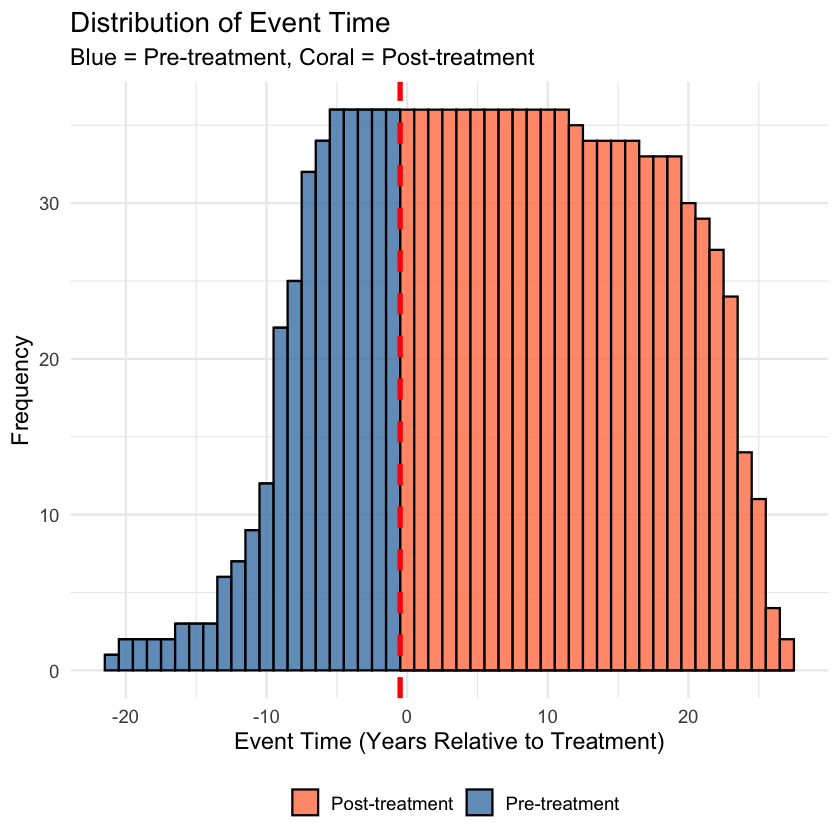

In [33]:
# Visualize the distribution of event times
event_time_plot <- df_es %>%
  filter(!is.na(event_time)) %>%
  ggplot(aes(x = event_time, fill = event_time < 0)) +
  geom_histogram(binwidth = 1, color = "black", alpha = 0.8) +
  geom_vline(xintercept = -0.5, color = "red", linetype = "dashed", size = 1.5) +
  scale_fill_manual(values = c("coral", "steelblue"), 
                    labels = c("Post-treatment", "Pre-treatment"),
                    name = "") +
  labs(
    title = "Distribution of Event Time",
    subtitle = "Blue = Pre-treatment, Coral = Post-treatment",
    x = "Event Time (Years Relative to Treatment)",
    y = "Frequency"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")

print(event_time_plot)

# Save the plot
ggsave("../output/event_time_distribution.png", event_time_plot, 
       width = 12, height = 6, dpi = 300)
cat("\nFigure saved to: ../output/event_time_distribution.png")

### Step 3: Choose Reasonable Bounds for Grouping Extreme Event Times

In [34]:
# Analyze distribution to choose bounds
cat("========================================================================\n")
cat("ANALYSIS FOR CHOOSING EVENT TIME BOUNDS\n")
cat("========================================================================\n")

event_times <- df_es$event_time[!is.na(df_es$event_time)]

cat("\nPercentiles of Event Time:\n")
percentiles <- quantile(event_times, probs = c(0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95))
print(percentiles)

cat("\nFrequency at extreme values:\n")
cat(sprintf("  Event time <= -10: %d obs (%.1f%%)\n", 
            sum(event_times <= -10), sum(event_times <= -10)/length(event_times)*100))
cat(sprintf("  Event time >= 10: %d obs (%.1f%%)\n", 
            sum(event_times >= 10), sum(event_times >= 10)/length(event_times)*100))

cat("\nRecommended bounds: -10 to 10\n")
cat("This captures the core distribution while grouping sparse tails.")

ANALYSIS FOR CHOOSING EVENT TIME BOUNDS

Percentiles of Event Time:
 5% 10% 25% 50% 75% 90% 95% 
 -9  -7  -2   6  15  20  22 

Frequency at extreme values:
ANALYSIS FOR CHOOSING EVENT TIME BOUNDS

Percentiles of Event Time:
 5% 10% 25% 50% 75% 90% 95% 
 -9  -7  -2   6  15  20  22 

Frequency at extreme values:
  Event time <= -10: 52 obs (4.4%)
  Event time >= 10: 483 obs (40.7%)

Recommended bounds: -10 to 10
This captures the core distribution while grouping sparse tails.  Event time <= -10: 52 obs (4.4%)
  Event time >= 10: 483 obs (40.7%)

Recommended bounds: -10 to 10
This captures the core distribution while grouping sparse tails.

In [35]:
# Set bounds for binning
LOWER_BOUND <- -10
UPPER_BOUND <- 10

# Create binned event time
df_es <- df_es %>%
  mutate(
    event_time_binned = case_when(
      is.na(event_time) ~ NA_real_,
      event_time < LOWER_BOUND ~ LOWER_BOUND,
      event_time > UPPER_BOUND ~ UPPER_BOUND,
      TRUE ~ event_time
    )
  )

cat(sprintf("Event time binned to range [%d, %d]\n", LOWER_BOUND, UPPER_BOUND))
cat("\nBinned event time distribution:\n")
table(df_es$event_time_binned, useNA = "ifany")

Event time binned to range [-10, 10]

Binned event time distribution:

Binned event time distribution:



 -10   -9   -8   -7   -6   -5   -4   -3   -2   -1    0    1    2    3    4    5 
  52   22   25   32   34   36   36   36   36   36   36   36   36   36   36   36 
   6    7    8    9   10 <NA> 
  36   36   36   36  483  429 

### Step 4: Why Do We Group Distant Event Times Together?

**Answer:**

We group very distant event times together for several important reasons:

1. **Statistical Power**: Extreme event times have very few observations, leading to imprecise estimates with large standard errors.

2. **Avoiding Multicollinearity**: Many event-time dummies with few observations can cause near-perfect collinearity.

3. **Focus on Relevant Window**: Policy-relevant dynamics typically occur close to treatment. Effects at very distant periods are less informative.

4. **Composition Effects**: At extreme lags/leads, only certain cohorts contribute, potentially introducing composition bias.

5. **Practical Interpretation**: Effects 20+ years before/after treatment are difficult to interpret as other confounders likely dominate.

### Step 5: Create Relative-Time Dummy Variables

In [36]:
# Filter to treated units only for event study
df_es_treated <- df_es %>%
  filter(treatment_year > 0)

# Create event time as factor with -1 as reference
# This automatically creates dummies with -1 omitted
df_es_treated <- df_es_treated %>%
  mutate(
    event_time_factor = factor(event_time_binned),
    # Relevel to make -1 the reference category
    event_time_factor = relevel(event_time_factor, ref = "-1")
  )

cat("Event time factor created with -1 as reference category\n")
cat("\nFactor levels:\n")
print(levels(df_es_treated$event_time_factor))

cat(sprintf("\nNumber of observations for event study: %d\n", nrow(df_es_treated)))

Event time factor created with -1 as reference category

Factor levels:
 [1] "-1"  "-10" "-9"  "-8"  "-7"  "-6"  "-5"  "-4"  "-3"  "-2"  "0"   "1"  
[13] "2"   "3"   "4"   "5"   "6"   "7"   "8"   "9"   "10" 

Number of observations for event study: 1188

Factor levels:
 [1] "-1"  "-10" "-9"  "-8"  "-7"  "-6"  "-5"  "-4"  "-3"  "-2"  "0"   "1"  
[13] "2"   "3"   "4"   "5"   "6"   "7"   "8"   "9"   "10" 

Number of observations for event study: 1188


---

## Part c) Event-Study Estimation

The event-study model:

$$Y_{it} = \alpha_i + \gamma_t + \sum_{k \neq -1} \beta_k \cdot \mathbf{1}[K_{it} = k] + X_{it}'\delta + \epsilon_{it}$$

In [37]:
# Estimate Event-Study model
event_study_model <- feols(
  asmrs ~ event_time_factor + pcinc + asmrh + cases | stfips + year,
  data = df_es_treated,
  cluster = ~stfips
)

cat("========================================================================\n")
cat("EVENT-STUDY REGRESSION RESULTS\n")
cat("========================================================================\n")
summary(event_study_model)

EVENT-STUDY REGRESSION RESULTS
EVENT-STUDY REGRESSION RESULTS


OLS estimation, Dep. Var.: asmrs
Observations: 1,188
Fixed-effects: stfips: 36,  year: 33
Standard-errors: Clustered (stfips) 
                        Estimate Std. Error   t value Pr(>|t|) 
event_time_factor-10   -6.148791   7.718843 -0.796595  0.43106 
event_time_factor-9    -7.318022   6.115817 -1.196573  0.23952 
event_time_factor-8    -4.430764   5.957583 -0.743718  0.46201 
event_time_factor-7    -2.708891   5.819362 -0.465496  0.64446 
event_time_factor-6    -2.136785   4.513974 -0.473371  0.63889 
event_time_factor-5    -3.788089   3.545175 -1.068520  0.29260 
event_time_factor-4    -0.619333   2.840652 -0.218025  0.82868 
event_time_factor-3    -3.139643   2.975579 -1.055137  0.29859 
event_time_factor-2    -0.654568   2.444916 -0.267726  0.79048 
event_time_factor0      1.209878   2.803174  0.431610  0.66867 
event_time_factor1     -0.312555   3.448384 -0.090638  0.92830 
event_time_factor2      0.765940   4.658407  0.164421  0.87035 
event_time_factor3      1.893053   3.5673

In [38]:
# Extract and store coefficient estimates
es_results <- tidy(event_study_model, conf.int = TRUE) %>%
  filter(str_detect(term, "event_time_factor")) %>%
  mutate(
    event_time = as.numeric(str_extract(term, "-?\\d+")),
    coefficient = estimate,
    std_error = std.error,
    ci_lower = conf.low,
    ci_upper = conf.high
  ) %>%
  select(event_time, coefficient, std_error, ci_lower, ci_upper, statistic, p.value)

# Add the reference period (t = -1)
reference_row <- tibble(
  event_time = -1,
  coefficient = 0,
  std_error = 0,
  ci_lower = 0,
  ci_upper = 0,
  statistic = NA_real_,
  p.value = NA_real_
)

es_results <- bind_rows(es_results, reference_row) %>%
  arrange(event_time)

cat("========================================================================\n")
cat("EVENT-STUDY COEFFICIENTS TABLE\n")
cat("========================================================================\n")
print(es_results)

EVENT-STUDY COEFFICIENTS TABLE
EVENT-STUDY COEFFICIENTS TABLE
# A tibble: 21 x 7
   event_time coefficient std_error ci_lower ci_upper statistic p.value
        <dbl>       <dbl>     <dbl>    <dbl>    <dbl>     <dbl>   <dbl>
 1        -10      -6.15       7.72   -21.8      9.52    -0.797   0.431
 2         -9      -7.32       6.12   -19.7      5.10    -1.20    0.240
 3         -8      -4.43       5.96   -16.5      7.66    -0.744   0.462
 4         -7      -2.71       5.82   -14.5      9.11    -0.465   0.644
 5         -6      -2.14       4.51   -11.3      7.03    -0.473   0.639
 6         -5      -3.79       3.55   -11.0      3.41    -1.07    0.293
 7         -4      -0.619      2.84    -6.39     5.15    -0.218   0.829
 8         -3      -3.14       2.98    -9.18     2.90    -1.06    0.299
 9         -2      -0.655      2.44    -5.62     4.31    -0.268   0.790
10         -1       0          0        0        0       NA      NA    
# i 11 more rows
# A tibble: 21 x 7
   event_time coeff

In [39]:
# Save event-study results
write.csv(es_results, "../output/event_study_coefficients.csv", row.names = FALSE)
cat("Event-study coefficients saved to: ../output/event_study_coefficients.csv")

Event-study coefficients saved to: ../output/event_study_coefficients.csv


Figure saved to: ../output/event_study_plot.png

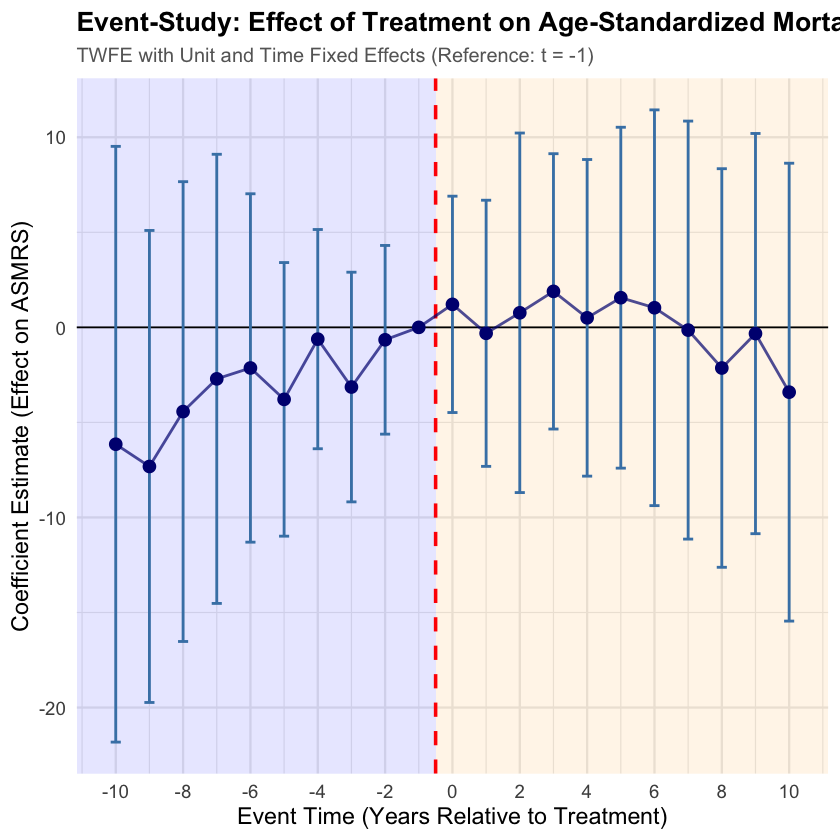

In [40]:
# Create Event-Study Plot
es_plot <- ggplot(es_results, aes(x = event_time, y = coefficient)) +
  # Shading for pre/post periods
  annotate("rect", xmin = -Inf, xmax = -0.5, ymin = -Inf, ymax = Inf, 
           fill = "blue", alpha = 0.1) +
  annotate("rect", xmin = -0.5, xmax = Inf, ymin = -Inf, ymax = Inf, 
           fill = "orange", alpha = 0.1) +
  # Reference lines
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = -0.5, color = "red", linetype = "dashed", size = 1) +
  # Confidence intervals
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
                width = 0.3, color = "steelblue", size = 0.8) +
  # Points and line
  geom_line(color = "navy", alpha = 0.7, size = 0.8) +
  geom_point(color = "navy", size = 3) +
  # Labels
  labs(
    title = "Event-Study: Effect of Treatment on Age-Standardized Mortality Rate",
    subtitle = "TWFE with Unit and Time Fixed Effects (Reference: t = -1)",
    x = "Event Time (Years Relative to Treatment)",
    y = "Coefficient Estimate (Effect on ASMRS)"
  ) +
  scale_x_continuous(breaks = seq(LOWER_BOUND, UPPER_BOUND, by = 2)) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 12, color = "gray40")
  )

print(es_plot)

# Save the plot
ggsave("../output/event_study_plot.png", es_plot, 
       width = 14, height = 8, dpi = 300)
cat("\nFigure saved to: ../output/event_study_plot.png")

### Interpretation of Event-Study Results

The event-study plot shows dynamic effects relative to the period just before treatment (t = -1, normalized to zero).

**Key observations:**

1. **Pre-trends (t < 0)**: Should be near zero if parallel trends holds
2. **Impact effects (t = 0)**: Immediate treatment effect
3. **Dynamic effects (t > 0)**: Evolution of effects post-treatment

**Caveat**: With staggered treatment, TWFE-based estimates may be biased due to "forbidden comparisons".

---

## Summary

### Key Results

1. **TWFE Estimate**: Average treatment effect estimated via two-way fixed effects
2. **Event-Study**: Dynamic treatment effects showing outcome trajectory before and after treatment

### Files Saved
- `../output/event_time_distribution.png`: Distribution of event times
- `../output/event_study_plot.png`: Event-study coefficient plot  
- `../output/event_study_coefficients.csv`: Coefficient estimates table

In [41]:
# Final summary
cat("========================================================================\n")
cat("SUMMARY OF QUESTION 1 RESULTS (R)\n")
cat("========================================================================\n")

cat(sprintf("\nTWFE Treatment Effect: %.4f (SE: %.4f)\n", twfe_coef, twfe_se))

pre_treatment <- es_results %>% filter(event_time < 0)
post_treatment <- es_results %>% filter(event_time >= 0)

cat("\nEvent-Study Coefficients Range:\n")
cat(sprintf("  Pre-treatment (t<0): %.4f to %.4f\n", 
            min(pre_treatment$coefficient), max(pre_treatment$coefficient)))
cat(sprintf("  Post-treatment (t>=0): %.4f to %.4f\n", 
            min(post_treatment$coefficient), max(post_treatment$coefficient)))

cat("\nOutput files generated:\n")
cat("  - event_time_distribution.png\n")
cat("  - event_study_plot.png\n")
cat("  - event_study_coefficients.csv\n")

SUMMARY OF QUESTION 1 RESULTS (R)

TWFE Treatment Effect: -2.5160 (SE: 2.2831)

Event-Study Coefficients Range:
SUMMARY OF QUESTION 1 RESULTS (R)

TWFE Treatment Effect: -2.5160 (SE: 2.2831)

Event-Study Coefficients Range:
  Pre-treatment (t<0): -7.3180 to 0.0000
  Post-treatment (t>=0): -3.4091 to 1.8931

Output files generated:
  - event_time_distribution.png
  - event_study_plot.png
  - event_study_coefficients.csv
  Pre-treatment (t<0): -7.3180 to 0.0000
  Post-treatment (t>=0): -3.4091 to 1.8931

Output files generated:
  - event_time_distribution.png
  - event_study_plot.png
  - event_study_coefficients.csv
